# Heart Failure Prediction:
Cardiovascular diseases (CVDs) are the number 1 cause of death globally, taking an estimated 17.9 million lives each year, which accounts for 31% of all deaths worldwide. Four out of 5CVD deaths are due to heart attacks and strokes, and one-third of these deaths occur prematurely in people under 70 years of age. Heart failure is a common event caused by CVDs and this dataset contains 11 features that can be used to predict a possible heart disease.

People with cardiovascular disease or who are at high cardiovascular risk (due to the presence of one or more risk factors such as hypertension, diabetes, hyperlipidaemia or already established disease) need early detection and management wherein a machine learning model can be of great help.

In [151]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder,StandardScaler
le = LabelEncoder()
ss = StandardScaler()
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier


## Attribute Information

 ### Age:
 Age of the patient [years]

### Sex:
Sex of the patient [M: Male, F: Female]

### ChestPainType:
Chest pain type [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-
Anginal Pain, ASY: Asymptomatic]

### RestingBP:
Resting blood pressure [mm Hg]

### Cholesterol:
Serum cholesterol [mm/dl]

### FastingBS: 
Fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise]

### RestingECG:
Resting electrocardiogram results [Normal: Normal, ST: having ST-T wave 
abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: 
showing probable or definite left ventricular hypertrophy by Estes' criteria]

### MaxHR:
Maximum heart rate achieved [Numeric value between 60 and 202]

### ExerciseAngina:
Exercise-induced angina [Y: Yes, N: No]

### Oldpeak:
Oldpeak = ST [Numeric value measured in depression]

### ST_Slope:
The slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: 
downsloping]

### HeartDisease:
Output class [1: heart disease, 0: Normal]


In [152]:
df = pd.read_csv("/kaggle/input/datasets/fedesoriano/heart-failure-prediction/heart.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## Data cleaning:

In [153]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [154]:
df.isnull().sum().sum()

np.int64(0)

In [155]:
df.duplicated().sum()

np.int64(0)

In [156]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [157]:
def remove_outliers(df, column):
   
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_filtered = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

    num_outliers = len(df) - len(df_filtered)
    print(f"\n--- Outlier Removal Summary for '{column}' ---")
    print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
    print(f"Original rows: {len(df)}, Filtered rows: {len(df_filtered)}")
    print(f"Number of outliers removed: {num_outliers}")

    return df_filtered

In [158]:
num_col = df.select_dtypes(include="number")
text_col = df.select_dtypes(include="object")

In [159]:
num_col.columns

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease'],
      dtype='object')

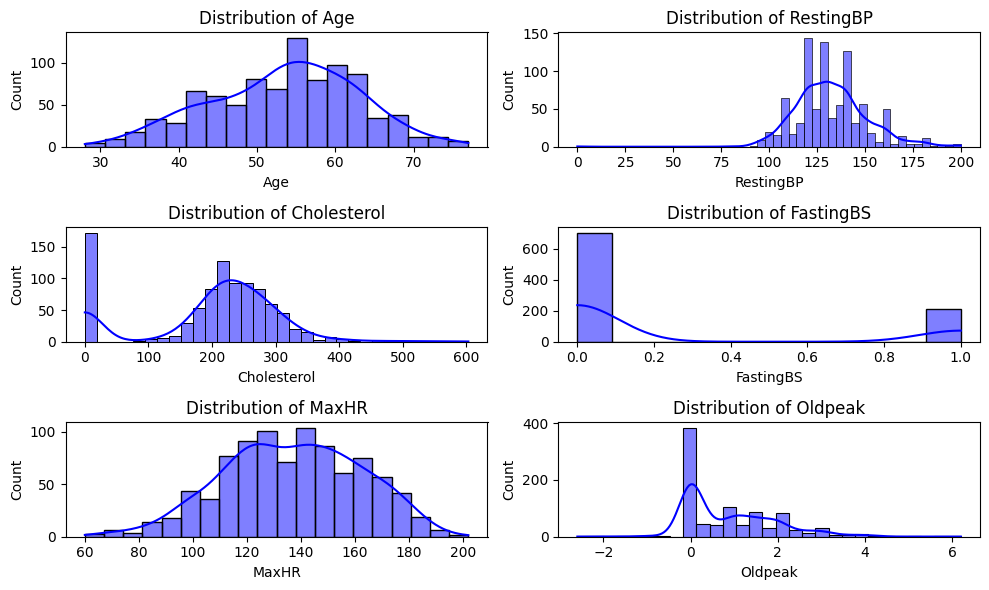

In [160]:
fig, axes = plt.subplots(3,2, figsize=(10,6))

sns.histplot(data=df, x='Age', kde=True, color="blue", edgecolor="black", ax=axes[0,0])
axes[0,0].set_title("Distribution of Age")

sns.histplot(data=df, x='RestingBP', kde=True, color="blue", edgecolor="black", ax=axes[0,1])
axes[0,1].set_title("Distribution of RestingBP")

sns.histplot(data=df, x='Cholesterol', kde=True, color="blue", edgecolor="black", ax=axes[1,0])
axes[1,0].set_title("Distribution of Cholesterol")

sns.histplot(data=df, x='FastingBS', kde=True, color="blue", edgecolor="black", ax=axes[1,1])
axes[1,1].set_title("Distribution of FastingBS")


sns.histplot(data=df, x="MaxHR", kde=True, color="blue", edgecolor="black", ax=axes[2,0])
axes[2,0].set_title("Distribution of MaxHR")


sns.histplot(data=df, x='Oldpeak', kde=True, color="blue", edgecolor="black", ax=axes[2,1])
axes[2,1].set_title("Distribution of Oldpeak")

plt.tight_layout()
plt.show()

In [161]:
df = remove_outliers(df,"RestingBP")
df = remove_outliers(df,"Cholesterol")
df = remove_outliers(df,"Oldpeak")




--- Outlier Removal Summary for 'RestingBP' ---
Q1: 120.00, Q3: 140.00, IQR: 20.00
Lower Bound: 90.00, Upper Bound: 170.00
Original rows: 918, Filtered rows: 890
Number of outliers removed: 28

--- Outlier Removal Summary for 'Cholesterol' ---
Q1: 174.25, Q3: 265.75, IQR: 91.50
Lower Bound: 37.00, Upper Bound: 403.00
Original rows: 890, Filtered rows: 713
Number of outliers removed: 177

--- Outlier Removal Summary for 'Oldpeak' ---
Q1: 0.00, Q3: 1.50, IQR: 1.50
Lower Bound: -2.25, Upper Bound: 3.75
Original rows: 713, Filtered rows: 701
Number of outliers removed: 12


## Exploratory Data Analysis (EDA):

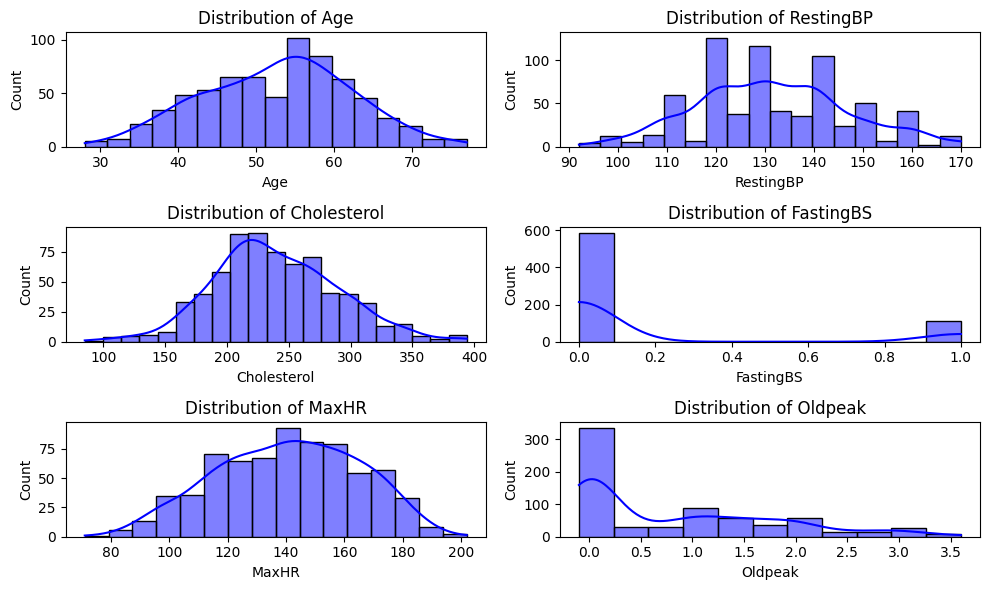

In [162]:
fig, axes = plt.subplots(3,2, figsize=(10,6))

sns.histplot(data=df, x='Age', kde=True, color="blue", edgecolor="black", ax=axes[0,0])
axes[0,0].set_title("Distribution of Age")

sns.histplot(data=df, x='RestingBP', kde=True, color="blue", edgecolor="black", ax=axes[0,1])
axes[0,1].set_title("Distribution of RestingBP")

sns.histplot(data=df, x='Cholesterol', kde=True, color="blue", edgecolor="black", ax=axes[1,0])
axes[1,0].set_title("Distribution of Cholesterol")

sns.histplot(data=df, x='FastingBS', kde=True, color="blue", edgecolor="black", ax=axes[1,1])
axes[1,1].set_title("Distribution of FastingBS")


sns.histplot(data=df, x="MaxHR", kde=True, color="blue", edgecolor="black", ax=axes[2,0])
axes[2,0].set_title("Distribution of MaxHR")


sns.histplot(data=df, x='Oldpeak', kde=True, color="blue", edgecolor="black", ax=axes[2,1])
axes[2,1].set_title("Distribution of Oldpeak")

plt.tight_layout()
plt.show()

In [163]:
df.shape

(701, 12)

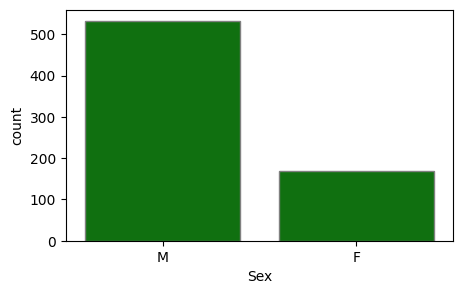

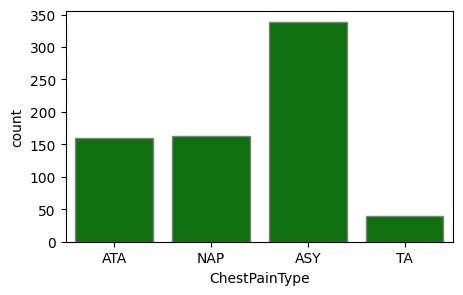

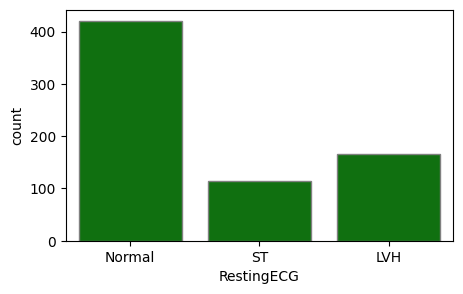

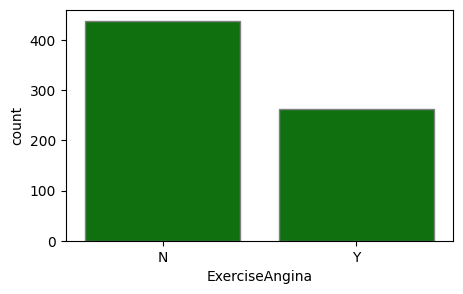

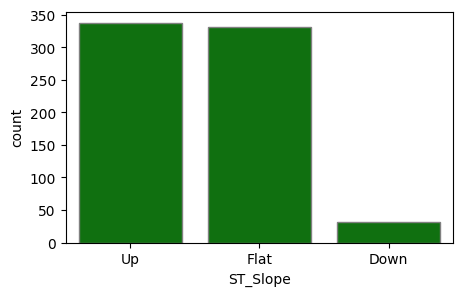

In [164]:
for text in text_col:
    plt.subplots(figsize=(5,3))
    sns.countplot(data=df, x=text, color="green",edgecolor="grey")
    plt.show()

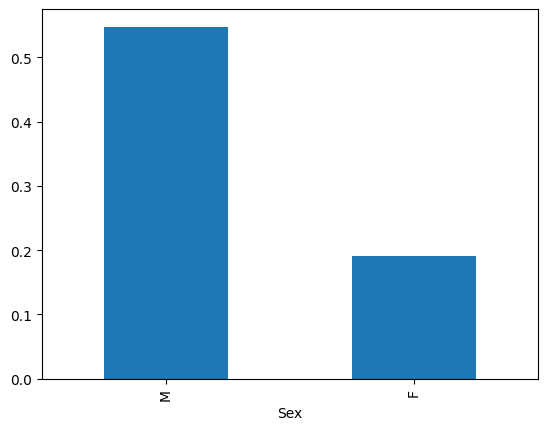

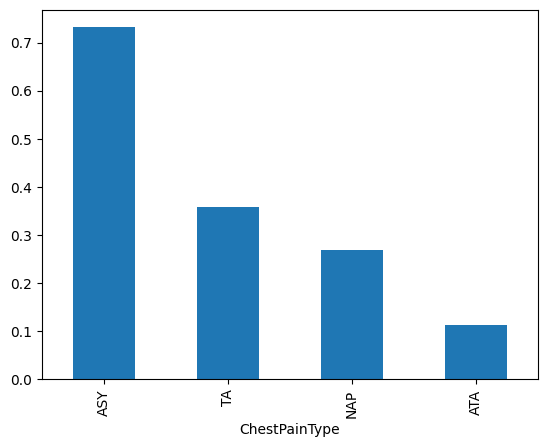

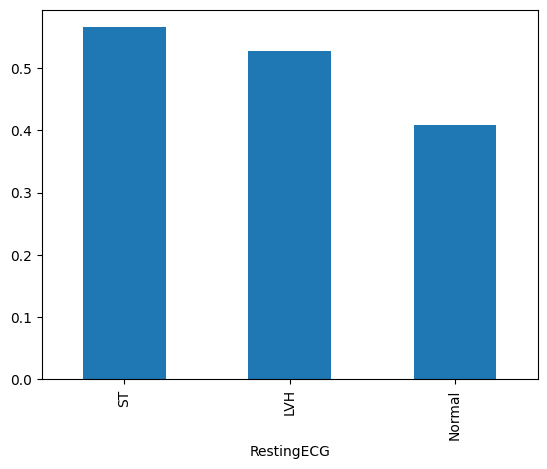

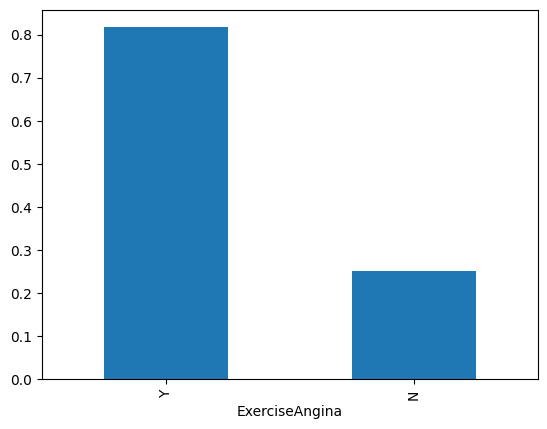

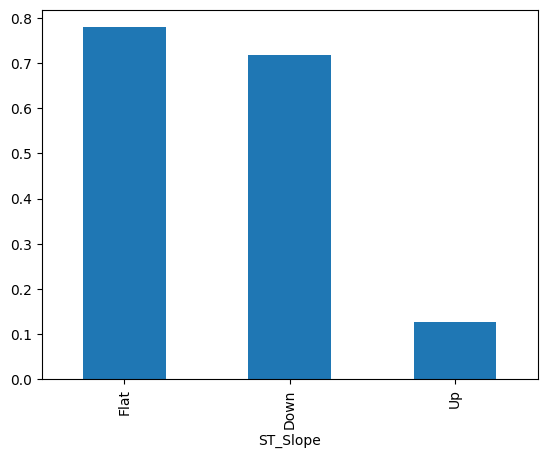

In [165]:
for text in text_col:
    plt.Figure(figsize=(8,4))
    df.groupby(text)["HeartDisease"].mean().sort_values(ascending=False).plot(kind="bar")
    plt.show()

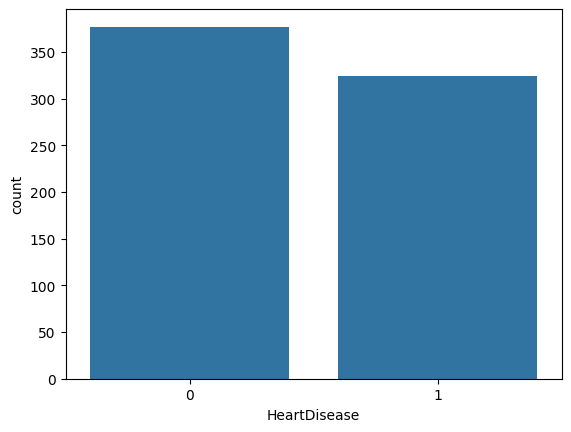

In [166]:
sns.countplot(data=df,x="HeartDisease")
plt.show()

In [167]:
for text in text_col:
    df[text]=le.fit_transform(df[text])

In [168]:
df.corr()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
Age,1.000000,0.064313,-0.081789,0.270978,0.070410,0.238198,-0.047132,-0.402908,0.242903,0.283910,-0.275980,0.305371
Sex,0.064313,1.000000,-0.134154,0.074468,-0.095546,0.102521,0.026699,-0.153232,0.212682,0.150280,-0.153438,0.305977
ChestPainType,-0.081789,-0.134154,1.000000,-0.012508,-0.094346,-0.000253,-0.028411,0.301849,-0.391748,-0.213927,0.227467,-0.390088
RestingBP,0.270978,0.074468,-0.012508,1.000000,0.087731,0.174486,0.040999,-0.128306,0.152283,0.191034,-0.130450,0.170454
Cholesterol,0.070410,-0.095546,-0.094346,0.087731,1.000000,0.031189,-0.080216,0.000913,0.104078,0.066638,-0.036495,0.093916
FastingBS,0.238198,0.102521,-0.000253,0.174486,0.031189,1.000000,0.043899,-0.112921,0.107009,0.068814,-0.151521,0.165226
RestingECG,-0.047132,0.026699,-0.028411,0.040999,-0.080216,0.043899,1.000000,-0.140232,0.078356,-0.038002,0.026701,0.005057
MaxHR,-0.402908,-0.153232,0.301849,-0.128306,0.000913,-0.112921,-0.140232,1.000000,-0.418839,-0.279658,0.353283,-0.394865
ExerciseAngina,0.242903,0.212682,-0.391748,0.152283,0.104078,0.107009,0.078356,-0.418839,1.000000,0.482370,-0.479131,0.549450
Oldpeak,0.283910,0.150280,-0.213927,0.191034,0.066638,0.068814,-0.038002,-0.279658,0.482370,1.000000,-0.597619,0.501168


## Data Preprocessing:

In [169]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [170]:
x = df[['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS','RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',]]
y = df['HeartDisease']

In [171]:
from imblearn.over_sampling import SMOTE

In [172]:
x, y = SMOTE().fit_resample(x,y)

In [173]:
x = ss.fit_transform(x)

In [174]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [175]:
y_train.shape

(603,)

## Model Selection:

### Logistic Regression

In [176]:
lr=LogisticRegression()
lr.fit(x_train,y_train)
lr_prd = lr.predict(x_test)
lr_prd2 = lr.predict(x_train)

In [177]:
from sklearn.metrics import accuracy_score, classification_report

In [178]:
accuracy_score(y_test,lr_prd)


0.9006622516556292

In [179]:
accuracy_score(y_train,lr_prd2)

0.8424543946932007

In [180]:
pd.DataFrame(classification_report(y_test,lr_prd,output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,0.835821,0.952381,0.900662,0.894101,0.906066
recall,0.933333,0.879121,0.900662,0.906227,0.900662
f1-score,0.881890,0.914286,0.900662,0.898088,0.901413
support,60.000000,91.000000,0.900662,151.000000,151.000000


### SVC:

In [181]:
svc= SVC()
svc.fit(x_train,y_train)
svc_prd = svc.predict(x_test)
svc_prd2 = svc.predict(x_train)

In [182]:
print(accuracy_score(y_test,svc_prd))
print(accuracy_score(y_train,svc_prd2))
pd.DataFrame(classification_report(y_test,svc_prd, output_dict=True))

0.9072847682119205
0.9021558872305141


,0,1,accuracy,macro avg,weighted avg
precision,0.848485,0.952941,0.907285,0.900713,0.911435
recall,0.933333,0.890110,0.907285,0.911722,0.907285
f1-score,0.888889,0.920455,0.907285,0.904672,0.907912
support,60.000000,91.000000,0.907285,151.000000,151.000000


### Decision Tree:

In [183]:
dtr = DecisionTreeClassifier()
dtr.fit(x_train,y_train)
dtr_prd = dtr.predict(x_test)
dtr_prd2 = dtr.predict(x_train)

In [184]:
print(accuracy_score(y_test,dtr_prd))
print(accuracy_score(y_train,dtr_prd2))

0.8410596026490066
1.0


### naive_bayes:

In [185]:
from sklearn.naive_bayes import BernoulliNB
nb = BernoulliNB()

In [186]:
nb.fit(x_train,y_train)
nb_prd = nb.predict(x_test)
nb_prd2 = nb.predict(x_train)

In [187]:
print(accuracy_score(y_test,nb_prd))
print(accuracy_score(y_train,nb_prd2))
pd.DataFrame(classification_report(y_test,nb_prd,output_dict=True))

0.8874172185430463
0.8308457711442786


,0,1,accuracy,macro avg,weighted avg
precision,0.820896,0.940476,0.887417,0.880686,0.892961
recall,0.916667,0.868132,0.887417,0.892399,0.887417
f1-score,0.866142,0.902857,0.887417,0.884499,0.888268
support,60.000000,91.000000,0.887417,151.000000,151.000000


###  K Neighbors:

In [195]:
from sklearn.neighbors import KNeighborsClassifier
knc = KNeighborsClassifier()
knc.fit(x_train,y_train)
knc_prd = knc.predict(x_test)
knc_prd2= knc.predict(x_train)

In [196]:
knc_prm = {
     "n_neighbors":[3,5],
   "p":[1,2],
   "metric":["manhattan","euclidean",'minkowski'],
   
}

In [197]:
knc_grid = GridSearchCV(knc,knc_prm,cv=5)

In [198]:
knc_grid.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'metric': ['manhattan', 'euclidean', 'minkowski'],
                         'n_neighbors': [3, 5], 'p': [1, 2]})

In [199]:
knc_prm_prd = knc_grid.predict(x_test)
knc_prm_prd2 = knc_grid.predict(x_train)

In [200]:
print(accuracy_score(y_test,knc_prm_prd))
print(accuracy_score(y_train,knc_prm_prd2))

0.8807947019867549
0.8955223880597015


In [194]:
knc_grid.best_params_

{'metric': 'manhattan', 'n_neighbors': 5, 'p': 1}

## conclusion:

Cardiovascular diseases are one of the leading global health issues, accounting for 31% of total deaths worldwide, creating the need for innovative tools and techniques for diagnosis. This study employed a dataset comprising 11 features and selected the machine learning model procedures to help in predictive analysis. Through predictive analysis, the purpose of the model is to help identify high-risk patients that are likely to develop heart problems in the future. The first step taken before modeling was outlier treatment to enhance data quality. After statistical analysis, it was found that more heart disease patients were male. Asymptomatic chest pain is marked as major clinical feature. The most valuable factors included age of the patient, sex, type of chest pain, exercise angina, oldpeak and slope. After constructing the model, the model selection is done based on accuracy. In this step, five models were applied and built to find the best diagnostic tool. The five models included Logistic Regression, SVC, Decision Tree, Naive Bayes and K-Neighbors classifier. The best model was SVC in terms of accuracy with 90%, followed by K-Neighbors with accuracy of 89%. The findings indicate SVC model would facilitate the decision-making process by producing accurate results and advance data-driven clinical decision-making to assist patients with medical management to avert or reduce the likelihood of premature stroke and heart attack.